In [1]:
import pandas as pd
import numpy as np
import glob
import re
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLM
import statsmodels.stats.multitest as smm

In [2]:
# Read in dataframe
cells = pd.read_csv('../data/cd34_clustering_results_patient_updated.csv', index_col=0)
cells.columns = cells.columns.str.replace('Unnamed: 0', 'FileName')

# Delete spare progression sample (there was a second later measurement which was associated with progression)
cells = cells.loc[cells['FileName'] != 'P02_SPD',:]
cells = cells.loc[~cells['FileName'].str.contains('P26'),:]
cells['FileName'] = cells['FileName'].str.replace('P02_SPD_2', 'P02_SPD')
cells.head()

,FileName,FlowSOM_metacluster_1,FlowSOM_metacluster_2,FlowSOM_metacluster_3,FlowSOM_metacluster_4,FlowSOM_metacluster_5,FlowSOM_metacluster_6,FlowSOM_metacluster_7,FlowSOM_metacluster_8,FlowSOM_metacluster_9,...,FlowSOM_metacluster_11,FlowSOM_metacluster_12,FlowSOM_metacluster_13,FlowSOM_metacluster_14,FlowSOM_metacluster_15,FlowSOM_metacluster_16,FlowSOM_metacluster_17,FlowSOM_metacluster_18,FlowSOM_metacluster_19,FlowSOM_metacluster_20
0,P08_C1_D8,309,396,630,243,27,30,1,2316,189,...,3148,168,1015,15,29,1225,720,54,0,183
1,P08_C7_D1,184,61,159,82,12,8,0,726,30,...,535,86,169,0,1,343,118,10,0,21
2,P08_C7_D22,75,9,36,21,5,0,0,88,10,...,60,66,24,2,1,50,14,15,0,3
3,P08_SPD,76,6,46,19,2,0,0,58,4,...,61,67,12,0,0,26,2,6,0,2
4,P24_C1_D1,2084,308,11708,1947,37,31,0,627,3,...,2351,222,34,4,11,13,28,32,19,7


In [3]:
# Read in patient outcomes
outcomes = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx')
outcomes_diagnosis_dict = dict(zip(outcomes['PID'], outcomes['Diagnosis']))
outcomes_c6_dict = dict(zip(outcomes['PID'], outcomes['Outcome_C6_revised_Vid']))
outcomes_c12_dict = dict(zip(outcomes['PID'], outcomes['Outcome_C12_CC486']))

In [4]:
# Map the filenames back to some clinical information
pid = {}
timepoint = {}
out_6 = {}
out_12 = {}
for i in cells['FileName']:
    if i.startswith('P'):
        x = i.split('_')[0]
        y = '_'.join(i.split('_')[1:])
        pid[i] = x
        timepoint[i] = y
        out_6[i] = outcomes_c6_dict[x]
        out_12[i] = outcomes_c12_dict[x]
    else:
        pid[i] = i
        timepoint[i] = 'Control'
        out_6[i] = 'Control'
        out_12[i] = 'Control'

cells['pid'] = cells['FileName'].map(pid)
cells['timepoint'] = cells['FileName'].map(timepoint)
cells['out_6'] =  cells['FileName'].map(out_6)
cells['out_12'] = cells['FileName'].map(out_12)

In [5]:
cells['pid'].value_counts()

pid
P18           5
P13           5
P03           5
P17           5
P07           5
P11           5
P10           5
P01           5
P02           4
P21           4
P22           4
P08           4
P04           4
P16           4
P14           4
P19           4
P12           4
P24           3
P05           3
P20           2
P25           2
P38           2
P28           2
P06           2
Control_10    1
Control_4     1
Control_7     1
Control_16    1
Control_5     1
Control_8     1
Control_2     1
Control_3     1
Control_15    1
Control_1     1
Control_9     1
Control_18    1
Control_13    1
Control_19    1
Control_17    1
Control_14    1
P27           1
P15           1
Control_11    1
Name: count, dtype: int64

In [6]:

# Delete the following samples as they have only a single measurement
cells = cells.loc[~cells['FileName'].str.contains('P27'),:]
cells = cells.loc[~cells['FileName'].str.contains('P15'),:]
print(cells.shape)

(109, 25)


In [7]:

cells['pid_timepoint'] = cells['pid'] + '_' +	cells['timepoint']

In [8]:
# Use a dictionary to add a column called time which will be used for plotting
time = {'C1_D1': 1, 'C1_D8': 8, 'C7_D1': 168, 'C7_D22': 190, 'C12_D29': 336,
    'Progression': 275,  'Control': 0.4}
    
cells['time'] = cells['timepoint'].map(time)
cells

,FileName,FlowSOM_metacluster_1,FlowSOM_metacluster_2,FlowSOM_metacluster_3,FlowSOM_metacluster_4,FlowSOM_metacluster_5,FlowSOM_metacluster_6,FlowSOM_metacluster_7,FlowSOM_metacluster_8,FlowSOM_metacluster_9,...,FlowSOM_metacluster_17,FlowSOM_metacluster_18,FlowSOM_metacluster_19,FlowSOM_metacluster_20,pid,timepoint,out_6,out_12,pid_timepoint,time
0,P08_C1_D8,309,396,630,243,27,30,1,2316,189,...,720,54,0,183,P08,C1_D8,non-responder_2,non-responder_2,P08_C1_D8,8.0
1,P08_C7_D1,184,61,159,82,12,8,0,726,30,...,118,10,0,21,P08,C7_D1,non-responder_2,non-responder_2,P08_C7_D1,168.0
2,P08_C7_D22,75,9,36,21,5,0,0,88,10,...,14,15,0,3,P08,C7_D22,non-responder_2,non-responder_2,P08_C7_D22,190.0
3,P08_SPD,76,6,46,19,2,0,0,58,4,...,2,6,0,2,P08,SPD,non-responder_2,non-responder_2,P08_SPD,NaN
4,P24_C1_D1,2084,308,11708,1947,37,31,0,627,3,...,28,32,19,7,P24,C1_D1,non-responder_2,NaN,P24_C1_D1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,Control_5,15,14,152,43,1,0,0,18,1,...,43,0,0,2,Control_5,Control,Control,Control,Control_5_Control,0.4
110,Control_16,31,94,352,299,2,55,2,454,26,...,578,1,1,66,Control_16,Control,Control,Control,Control_16_Control,0.4
111,Control_10,0,4,47,8,0,1,0,583,0,...,52,1,0,1,Control_10,Control,Control,Control,Control_10_Control,0.4
112,Control_4,9,7,89,26,0,1,0,28,0,...,38,0,1,1,Control_4,Control,Control,Control,Control_4_Control,0.4


In [9]:
# Read in an excel sheet which details the cell to cluster annotation
cluster_result = pd.read_csv('../data/cd34_annotation.csv')
cluster_dict = dict(zip(cluster_result['cluster'], cluster_result['cell_type'].str.replace(' ', '_')))
cluster_dict

del cluster_result

# Create a dictionary which specifies all the annotations to a cluster
cell_dict = {}
for key, value in cluster_dict.items():
    cell_dict.setdefault(value, []).append(str(key))
cell_dict

{'CD33_HSC': ['1'],
 'Myeloid_precursor': ['2', '4', '5', '8', '9', '10', '14', '17', '19', '20'],
 'HSC': ['3'],
 'CD56_pos': ['6', '7', '15'],
 'MEP': ['11', '18'],
 'GMP': ['12', '13'],
 'CMP': ['16']}

In [10]:
# Edit the colnames
cells.columns = cells.columns.str.replace('FlowSOM_metacluster_', '')
cells.head()

,FileName,1,2,3,4,5,6,7,8,9,...,17,18,19,20,pid,timepoint,out_6,out_12,pid_timepoint,time
0,P08_C1_D8,309,396,630,243,27,30,1,2316,189,...,720,54,0,183,P08,C1_D8,non-responder_2,non-responder_2,P08_C1_D8,8.0
1,P08_C7_D1,184,61,159,82,12,8,0,726,30,...,118,10,0,21,P08,C7_D1,non-responder_2,non-responder_2,P08_C7_D1,168.0
2,P08_C7_D22,75,9,36,21,5,0,0,88,10,...,14,15,0,3,P08,C7_D22,non-responder_2,non-responder_2,P08_C7_D22,190.0
3,P08_SPD,76,6,46,19,2,0,0,58,4,...,2,6,0,2,P08,SPD,non-responder_2,non-responder_2,P08_SPD,NaN
4,P24_C1_D1,2084,308,11708,1947,37,31,0,627,3,...,28,32,19,7,P24,C1_D1,non-responder_2,NaN,P24_C1_D1,1.0


In [11]:
# Sum together the columns which belong to specific cell types and delete the leftover columns
for new_col, cols_to_sum in cell_dict.items():
    cells[new_col] = cells[cols_to_sum].sum(axis=1)

# Drop columns with numerical names
cols = [str(i + 1) for i in range(20)]
cells.drop(columns=cols, inplace=True)

del cols
cells.head()

,FileName,pid,timepoint,out_6,out_12,pid_timepoint,time,CD33_HSC,Myeloid_precursor,HSC,CD56_pos,MEP,GMP,CMP
0,P08_C1_D8,P08,C1_D8,non-responder_2,non-responder_2,P08_C1_D8,8.0,309,4092,630,60,3202,1183,1225
1,P08_C7_D1,P08,C7_D1,non-responder_2,non-responder_2,P08_C7_D1,168.0,184,1050,159,9,545,255,343
2,P08_C7_D22,P08,C7_D22,non-responder_2,non-responder_2,P08_C7_D22,190.0,75,152,36,1,75,90,50
3,P08_SPD,P08,SPD,non-responder_2,non-responder_2,P08_SPD,NaN,76,93,46,0,67,79,26
4,P24_C1_D1,P24,C1_D1,non-responder_2,NaN,P24_C1_D1,1.0,2084,2981,11708,42,2383,256,13


In [12]:
# Read in a dataframe which details the number of myeloid cells 
# so that I can figure out how to control for the number of stem and progenitor cells in each sample
hspc = pd.read_csv('../data/patient_metacluster_table_patient_updated.csv') #total number of myeloid cells
#cells = cells.drop(cells.loc[:, 'FlowSOM_metacluster_1': 'FlowSOM_metacluster_20'], axis = 1)
hspc['total_cells'] = hspc.loc[:, 'metacluster_1' :'metacluster_9'].sum(axis = 1)

total_dict = dict(zip(hspc['FileNames'].str.replace('_Myeloid_Panel', ''),  hspc['total_cells']))

cells['total_cells']= cells['FileName'].map(total_dict)

In [13]:
# Create a list so that I can delete the samples where I acquired a C7D22 but the patient dropped out for
# reasons unrelated to the disease or treatment note that these patients have an NA in the outcome_12 column
to_del = []
time_to_keep = ['non-responder_2', 'responder_1', 'Control']
for x, y, in zip(cells['pid_timepoint'], cells['out_12']):
    if (x.__contains__('C7_D22')) & (y not in time_to_keep):
        to_del.append(x)
to_del
print(cells.shape)
cells = cells.loc[~cells['pid_timepoint'].isin(to_del), :]
print(cells.shape)

del to_del

(109, 15)
(107, 15)


In [14]:
# Add a column called best response which details the best clinical response of each patient
# if a patient is called a responder at any timepont they are called a responder even if they eventually progress
best_response = ['responder' if 'responder_1' in (x, y)
                 else 'Healthy' if y == 'Healthy'
                 else 'non_responder'
                 for x, y in zip(cells['out_6'], cells['out_12'])]

cells['best_response'] = best_response

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_6612/3511733236.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cells['best_response'] = best_response


In [15]:
# Create a list of patients which have a C7D22 but not a C7D1 measurement
patient_tp_to_keep = []
for x in cells['pid'].unique():
    z = cells.loc[cells['pid'] == x, :]
    if ('C7_D1' not in z['timepoint'].to_list()) and ('C7_D22' in z['timepoint'].to_list()):
        patient_tp_to_keep.append(str(x) + '_C7_D22') # append the actual pid_timepoint value

# Filter the dataframe to include only C1D1 and C7D1 measurements. Also include patients with a C7D22  
print(cells.shape)
tp_to_keep = ['C1_D1', 'C7_D1']
cells = cells.loc[(cells['timepoint'].isin(tp_to_keep)) | (cells['pid_timepoint'].isin(patient_tp_to_keep)), :]
print(cells.shape)

del patient_tp_to_keep
del tp_to_keep

(107, 16)
(40, 16)


In [16]:
# Create a dataframe with the percentage of CD34 positive cells
cells1 = cells.copy()
cells1 = cells1.loc[cells1['best_response'] != 'Control', :]

cells1[cells1.loc[:, 'CD33_HSC':'CMP'].columns] = cells1.loc[:, 'CD33_HSC':'CMP'].astype(float)
cells1[cells1.loc[:, 'CD33_HSC':'CMP'].columns] = cells1.loc[:, 'CD33_HSC':'CMP'].divide(cells1.loc[:, 'total_cells'], axis=0) * 100

cells1['time_point1'] = ((cells1['timepoint'] == 'C7_D1') | (cells1['timepoint'] == 'C7_D22')).astype(int)
cells1['timepoint'] = cells1['timepoint'].str.replace('C7_D22', 'C7_D1')

In [17]:
# Create a function to run the mixed-effects model for a single column
def run_mixed_model(df, column):
    model_data = df[['pid', 'time_point1', column]].copy()
    model_data.columns = ['pid', 'time_point1', 'value']
    
    # Fit a linear mixed-effects model
    model = smf.mixedlm('value ~ time_point1', model_data, groups=model_data['pid'])
    result = model.fit()
    
    return result

In [18]:
# Run the analysis for each relevant column
r_results = {}
nr_results = {}
timepoint = ['C1_D1', 'C7_D1']
for i in cells1['best_response'].unique():
    a = cells1.loc[(cells1['best_response'] == i)  & (cells1['timepoint'].isin(timepoint)), :]
    for column in a.columns[7:14]:  # Adjust the range as needed
        print(f"Analyzing {column}:")
        result = run_mixed_model(a, column)
        print(result.summary())
        print('\n')
        if i == 'responder':
            r_results[column] = result
        elif i == 'non_responder':
            nr_results[column] = result


Analyzing CD33_HSC:
        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: value   
No. Observations: 11      Method:             REML    
No. Groups:       8       Scale:              0.0074  
Min. group size:  1       Log-Likelihood:     -11.5104
Max. group size:  2       Converged:          Yes     
Mean group size:  1.4                                 
------------------------------------------------------
            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------
Intercept    0.768    0.431  1.783 0.075 -0.076  1.612
time_point1 -0.056    0.070 -0.801 0.423 -0.194  0.081
Group Var    1.470   19.315                           



Analyzing Myeloid_precursor:
        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: value   
No. Observations: 11      Method:             REML    
No. Groups:       8       Scale:              2.1997  
Min. group size:  1       Log-L

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: value   
No. Observations: 29      Method:             REML    
No. Groups:       16      Scale:              27.5617 
Min. group size:  1       Log-Likelihood:     -86.1134
Max. group size:  2       Converged:          Yes     
Mean group size:  1.8                                 
------------------------------------------------------
            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------
Intercept    2.557    1.422  1.798 0.072 -0.231  5.345
time_point1 -1.634    1.954 -0.836 0.403 -5.463  2.195
Group Var    0.747    1.443                           



Analyzing CD56_pos:
        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: value   
No. Observations: 29      Method:             REML    
No. Groups:       16      Scale:              0.2519  
Min. group size:  1       Log-Likelihood:     -22.5775
Max. 

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [19]:
# Create dictionaries with the the cell type and the associated p-value
r_pval_dict = {}
nr_pval_dict = {}
for i in r_results:
    r_pval_dict[i] = r_results[i].pvalues[1]
for i in nr_results:
    nr_pval_dict[i] = nr_results[i].pvalues[1]
    

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_6612/4269484933.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r_pval_dict[i] = r_results[i].pvalues[1]
/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_6612/4269484933.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r_pval_dict[i] = r_results[i].pvalues[1]
/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_6612/4269484933.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by posit

In [20]:
# Update the p-values in each dictionary to account for multiple testing hypothesis
def correct_p_values(dict1, dict2):
    # Combine p-values from both dictionaries
    all_p_values = list(dict1.values()) + list(dict2.values())
    
    # Perform FDR correction
    rejected, corrected_p_values, _, _ = smm.multipletests(all_p_values, method='fdr_bh')
    
    # Split the corrected p-values back into two lists
    split_index = len(dict1)
    corrected_dict1 = corrected_p_values[:split_index]
    corrected_dict2 = corrected_p_values[split_index:]
    
    # Update the original dictionaries with corrected p-values
    for (key, _), corrected_p in zip(dict1.items(), corrected_dict1):
        dict1[key] = corrected_p
    
    for (key, _), corrected_p in zip(dict2.items(), corrected_dict2):
        dict2[key] = corrected_p
    
    return dict1, dict2

# Apply the correction
r_pval_dict1, nr_pval_dict1 = correct_p_values(r_pval_dict, nr_pval_dict)

# Print the results
print("Corrected dict1:", r_pval_dict1)
print("Corrected dict2:", nr_pval_dict1)


Corrected dict1: {'CD33_HSC': 0.335973722823248, 'Myeloid_precursor': 0.335973722823248, 'HSC': 0.4934424662010501, 'CD56_pos': 0.25949505731530664, 'MEP': 0.335973722823248, 'GMP': 0.023499187283046966, 'CMP': 0.25949505731530664}
Corrected dict2: {'CD33_HSC': 0.4934424662010501, 'Myeloid_precursor': 0.7913955769926148, 'HSC': 0.335973722823248, 'CD56_pos': 0.25949505731530664, 'MEP': 0.38823312138469174, 'GMP': 0.5695764550459447, 'CMP': 0.25949505731530664}


In [21]:
# Create a function to make sure the the negative sign in number is smaller
import re

def text_to_int(text_obj):
    # Get the text content from the text object
    text_content = text_obj.get_text()
    
    # Replace Unicode minus sign (U+2212) with ASCII minus sign
    text_content = text_content.replace('\u2212', '-')
    
    # Remove any non-digit characters, but keep the minus sign at the beginning if present
    cleaned_text = re.sub(r'^-?\D*(-?\d+).*$', r'\1', text_content)
    cleaned_text = cleaned_text.replace("''", "")
    try:
        # Try to convert the cleaned string to an integer
        return int(cleaned_text)
    except ValueError:
        print(f"Could not convert '{text_content}' to an integer.")
        return None


In [22]:
# Create a function to add significance stars to my graphs
def add_significance_stars(ax, x, y, p_value, is_responder, fontsize=8):
    # Map p-value thresholds to stars
    thresholds = [(0.0001, '****'), (0.001, '***'), (0.01, '**'), (0.05, '*')]
    
    stars = next((s for threshold, s in thresholds if p_value < threshold), None)
    if not stars:
        return
    
    y_limit = ax.get_ylim()[1]
    bar_width = 0.35
    offset = 5.08  # Distance between line and star center
    
    if is_responder:
        # For responders (top): line first, then stars above it
        line_y = y_limit * 0.80
        star_y = line_y + offset
    else:
        # For non-responders (bottom): line first, then stars below it
        line_y = y_limit * -0.80
        star_y = line_y - (offset * 2.5)
    
    # Add horizontal line
    color = 'black' #if is_responder else '#fe9003'
    ax.hlines(y=line_y, xmin=x - bar_width/2, xmax=x + bar_width/2, 
              colors=color, linewidth=0.8, linestyle='-')
    
    # Add the stars with centered alignment for symmetry
    ax.text(x, star_y, stars, ha='center', va='center', fontsize=fontsize)

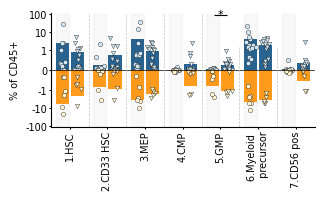

In [23]:
# Plot the change in cells as a percent of CD34 positive cells
fig, ax = plt.subplots(figsize=(6.69 * (7/14), 2.1))  # Swapped dimensions back

plt.rcParams['svg.fonttype'] = 'none' # export font as editable text
plt.rcParams['pdf.fonttype'] = 'truetype' # export font as editable text
plt.rcParams['axes.unicode_minus'] = False 

# Define colors for different times
colors = {'non_responder': '#fe9003', 'responder': '#115284'}

dot_colors = {'non_responder': '#FFF3CD', 'responder':  '#D0E8F5'}

markers = {'C1_D1': 'o', 'C7_D1': 'v'}

# Create a dictionary to help color each dot


# Define the categories and their positions on the x-axis
categories = ['HSC', 'CD33_HSC', 'MEP', 'CMP', 'GMP', 'Myeloid_precursor', 'CD56_pos']
x_positions = np.arange(len(categories))  # Back to x positions

# Set the width of each bar
bar_width = 0.35

mean_values = cells1.groupby(['best_response', 'timepoint'])[categories].mean()
time_offsets = {'C1_D1': -bar_width/2 - 0.025, 'C7_D1': bar_width/2 + 0.025}


ax.bar(x_positions + time_offsets['C1_D1'], bottom= -100,
       height=200, 
       width=bar_width,
       facecolor='lightgrey', edgecolor='lightgrey', alpha=0.15)

for outcome in ['responder', 'non_responder']:            # <-- hyphen to match data
    multiplier = 1 if outcome == 'responder' else -1

    for time, offset in time_offsets.items():
        values = mean_values.loc[outcome, time]
        ax.bar(x_positions + offset, values * multiplier, bar_width,  # <-- fixed arg order
               facecolor=colors[outcome], edgecolor=None,
               alpha=0.9, label=f'{outcome} - {time}')

        subset = cells1[(cells1['best_response'] == outcome) & (cells1['timepoint'] == time)]
        for i, category in enumerate(categories):
            x_jitter = np.random.normal(0, 0.05, size=len(subset))   
            ax.scatter(x_positions[i] + offset + x_jitter,
                       subset[category] * multiplier,                  
                       marker=markers[time],
                       facecolor=dot_colors[outcome],
                       edgecolor='black', linewidth=0.25, alpha=1, s=10)
    

# Add a horizontal line (formerly vertical)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Add vertical lines (formerly horizontal)
for i in range(len(categories) -1):
    if i <= 3:
        ax.axvline(x=i + bar_width + 0.15, ymax=1, color='silver', linestyle='--', linewidth=0.5)
    elif i >= 4:
        ax.axvline(x=i + bar_width + 0.15, ymax=0.7, color='silver', linestyle='--', linewidth=0.5)

# Set labels and other properties
ax.tick_params(axis='both', labelsize=7, pad=1, length=1.5)    
ax.set_xticks(range(len(categories)))  # Back to x-ticks
ax.set_ylim(bottom=-115, top=115)  # Back to ylim
ax.set_yscale('symlog', linthresh=1)
labels = [i.replace('_', ' ') for i in categories]
labels= [str(x+1) + '.' + y for x,y in enumerate(labels)]
labels = [i.replace('Myeloid precursor', 'Myeloid \n precursor') for i in labels]

ax.set_xticklabels(labels=labels, fontsize=7, rotation=90)  # Rotated x-labels

# After setting your y-limits but before saving
yticks = ax.get_yticks()
ax.set_yticks(yticks)
ax.set_yticklabels([str(int(tick)) if tick.is_integer() else str(tick) for tick in yticks])


# Normal axis limits (no inversion needed)
ax.set_xlim(-0.5, 6.5)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_ylabel('% of CD45+', fontsize=7)  # Back to ylabel

# Add legend (same as before)
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label='C1',
                              markerfacecolor='grey', markeredgewidth=1, markeredgecolor='grey', markersize=5),
                   plt.Line2D([0], [0], marker='v', color='w', label='C7',
                             markerfacecolor='grey', markeredgewidth=1, markeredgecolor='grey', markersize=5),
                   plt.Line2D([0], [0], linestyle='', color='#115284', label='Responder'),
                   plt.Line2D([0], [0], linestyle='', color='#fe9003', label='Non-responder')]

labelcolor = ['black', 'black', '#115284', '#fe9003']

# Add significance stars after setting the y-limits
for outcome in ['responder', 'non_responder']:
    for i, category in enumerate(categories):
        p_value = r_pval_dict1[category] if outcome == 'responder' else nr_pval_dict1[category]
        add_significance_stars(ax, x_positions[i], 0, p_value, outcome == 'responder')

fig.tight_layout()
# fig.savefig('../results/cell_types_graphs_percent_cd45_with_labels_vertical.png', pad_inches=0.1, dpi=600)
fig.savefig('../results/cell_types_graphs_percent_cd45_with_labels_vertical.pdf', bbox_inches='tight', pad_inches=0.01, dpi=300)